# Overview
---

1. Hierarchical coordinate systems
2. Need to determine orbital parameters to setup Satellite to Ground Link
3. Array size
    * Lattice discussion
    * Need to take high/level gain or information about pictures to determine antenna lattice for phased array

This example notebook is used to emulate the design of a Starlink user terminal.

# Phased Array Lattices
---


If the array is formed with a rectangular lattice, the maximum grating lobe free spacing is given by

$$
\begin{equation}
d_{max,rect.}=\frac{\lambda}{1+\sin\theta_{max}}
\end{equation}
$$

At 12.7 GHz and maximum scan of 60 degrees we get $d_{max,rectangular}=1.27$cm.

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from matplotlib import pylab as plt
from IPython.display import Markdown, HTML, display

In [2]:
from xant import ureg
from xant.antenna import phasedarray, common
from xant.plotting import plot_antenna_pattern, plot_lm_h3
from hics import HCS, GLOBAL_CS
from hics import plotting as hcsplt
from hics.geo import tle
from datetime import datetime, timezone, timedelta
# from propagator.rflink import calculate_spatial_link, view_link_horizon

import numpy as np
import xarray as xr
from scipy.spatial.transform import Rotation

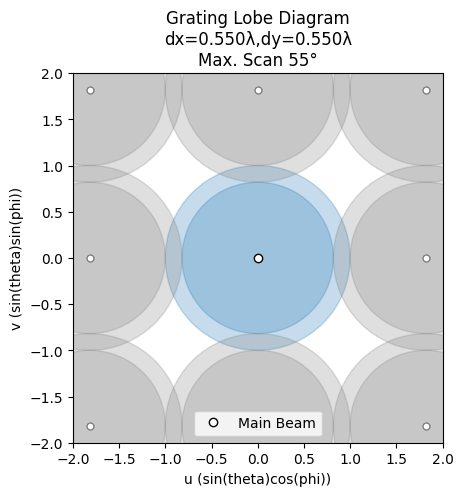

In [3]:
max_scan = 55 * ureg.degree
dxrect = 1 / (1 + np.sin(max_scan))
dxrect
ax = phasedarray.plot_grating_lobe_diagram(
    dxrect, dxrect, (0 * ureg.degree, 0 * ureg.degree), "rectangular", max_scan, figsize=None
)


## Triangular lattice
---
However, we have seen from pictures of the ground terminal that a triangular lattice is used - and it would make sense that both the ground terminal and satellite would use the same lattice for the Ku-band aperture. There are advantages of triangular lattices because each cell is a hexagon which efficiently tiles the aperture face using fewer elements (approximately 15% fewer) for the same maximum scanning. The maximum grating lobe free spacing for a triangular array is given by

$$
\begin{equation}
d_{max,tri.}=\frac{2}{\sqrt{3}}\left(\frac{\lambda}{1+\sin\theta_{max}}\right)
\end{equation}
$$

Generally, the lattice space is slightly smaller than the maximum spacing as the edge of the grating lobe will start to appear reducing the gain. So for this example let's assume the spacing is
$d_{triangular}=0.61\lambda =1.44$ cm.

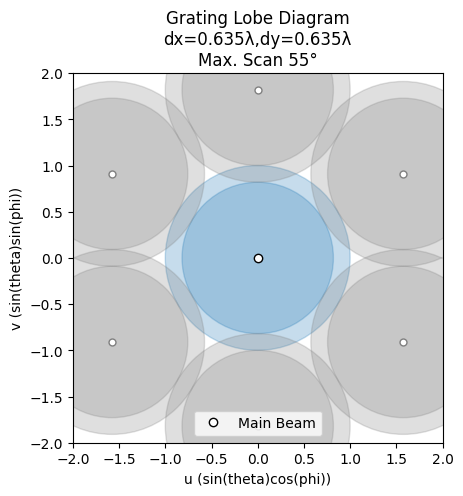

In [ ]:
dxtriang = dxrect * 2 / np.sqrt(3)
ax = phasedarray.plot_grating_lobe_diagram(
    dxtriang, dxtriang, (0 * ureg.degree, 0 * ureg.degree), "triangular", max_scan, figsize=None
)

# Orbit Coordinate Systems

In [9]:
from pathlib import Path

In [10]:
Path(".").resolve()

WindowsPath('C:/Users/robsc/Documents/Github/xant/examples')

In [ ]:
tle.check_celestrak_tle(Path("."), "starlink")

True

In [8]:
boulder_latlon = (40.0150, -105.2705)
time_search = datetime.now().astimezone().astimezone(timezone.utc)
closest_satellite, sats = tle.get_closest_from_tle(*boulder_latlon, "starlink", time_search)
starlinkcs = tle.satellite_to_cs(
    closest_satellite, t0=time_search, npts=11, tdelta=timedelta(seconds=10)
)

2026-04-15 09:29:58.215 | INFO     | hics.geo.tle:get_closest_from_tle:49 - Closest satellite: STARLINK-11247 [DTC]
2026-04-15 09:29:58.215 | INFO     | hics.geo.tle:get_closest_from_tle:50 - Distance: 441.17 km
2026-04-15 09:29:58.216 | INFO     | hics.geo.tle:get_closest_from_tle:53 - Satellite ECEF: [-3915436.87744472 -1253319.6549665   5288445.26524115]
2026-04-15 09:29:58.217 | INFO     | hics.geo.tle:get_closest_from_tle:54 - Satellite Latitude, Longitude: 52.3162 degrees,-162.2503 degrees
2026-04-15 09:29:58.230 | DEBUG    | hics.geo.tle:satellite_to_cs:44 - TARGET lat,lon: 38.375728043509866, -105.52755588911295
2026-04-15 09:29:58.233 | DEBUG    | hics.geo.tle:satellite_to_cs:45 - Target ECEF: [-1340287.79214307 -4823911.33665072  3938223.87729065]
2026-04-15 09:29:58.236 | DEBUG    | hics.geo.tle:satellite_to_cs:44 - TARGET lat,lon: 38.797968094427794, -104.92958027091913
2026-04-15 09:29:58.238 | DEBUG    | hics.geo.tle:satellite_to_cs:45 - Target ECEF: [-1282338.68604346 -4

In [9]:
m = hcsplt.showcs_leafmap(starlinkcs)
m

In [ ]:
f0 = 11.7 * ureg.GHz
lam0 = (ureg.speed_of_light / f0).to("cm")
lam_min = (ureg.speed_of_light / (12.7 * ureg.GHz)).to("cm")
max_scan = 60 * ureg.degree
l = lam_min / 2
# dx =dxtriang*lam_min # This is approximately 1.5cm
dx = 1.5 * ureg.cm
f0 = [11.7] * ureg.GHz

# Element Efficiency
el_eff = np.sqrt(0.8)  # Assume 80% efficient

nx = 32
ny = 38

nsubx = 16
nsuby = 2

req = dict(theta=np.linspace(-90, 90, 1801) * ureg.degree, phi=[0] * ureg.degree)

In [ ]:
dishy_base = HCS.from_crs(
    (boulder_latlon[0] * ureg.degree, boulder_latlon[1] * ureg.degree, 10 * ureg.ft), hagl=True
)
dishy_face = HCS(
    (0, 0, 0) * ureg.m,
    reference=dishy_base,
    rotation=Rotation.from_euler("ZYZ", [0, -20, 90], degrees=True),
)  # Looks like is says to pivot 20deg off zenith

csref_gnd = HCS((0, 0, 0) * ureg.m, reference=dishy_face)
csref90_gnd = HCS(
    (0, 0, 0) * ureg.m,
    rotation=Rotation.from_euler("ZYZ", [90, 0, 0], degrees=True),
    reference=csref_gnd,
)

2026-04-15 09:31:26.913 | INFO     | hics.geo.downloader:build_index:231 - Starting index build/update for C:\Users\robsc\AppData\Local\hics\terrain...
2026-04-15 09:31:26.957 | INFO     | hics.geo.downloader:build_index:312 - Index build/update complete.
2026-04-15 09:31:26.959 | INFO     | hics.geo.downloader:get_geospatial_data:570 - Searching bounding box -105.2706,40.0149,-105.2704,40.015100000000004
2026-04-15 09:31:26.964 | INFO     | hics.geo.downloader:query:353 - R-tree query found 31 tiles intersecting the AOI.
2026-04-15 09:31:26.965 | INFO     | hics.geo.downloader:get_geospatial_data:573 - Found 3dep-seamless files {'n41w106-1': {'source': '3dep-seamless', 'tile_name': 'n41w106-1', 'date': 20150717, 'path': 'C:\\Users\\robsc\\AppData\\Local\\hics\\terrain\\USGS30-n41w106-1-30m-20150717.tif', 'bbox': [-106.00166666666748, 39.99833333285117, -104.99833333285117, 41.00166666666747], 'gsd': 30}, 'n40w106-1': {'source': '3dep-seamless', 'tile_name': 'n40w106-1', 'date': 201803

In [ ]:
e0g = common.TE10Aperture(l, l, f0, hcs=csref_gnd)
e90g = common.TE10Aperture(l, l, f0, hcs=csref90_gnd)

egrh = (e0g + e90g * 1j) * el_eff / np.sqrt(2)

In [ ]:
# https://www.youtube.com/watch?v=AlvIWF0AXI0&t=781s
# 38 x 27 (approx) call it 38x28
nx_dishy = 38
ny_dishy = 28
nsubx_dishy = 19
nsuby_dishy = 2

sub_arr_dishy = phasedarray.AntennaArray.triangular(
    egrh, nsubx_dishy, nsuby_dishy, dx, cs_reference=csref_gnd
)

nfullx_dishy = int(nx_dishy / nsubx_dishy)
nfully_dishy = int(ny_dishy / nsuby_dishy)

fulldx_dishy = nsubx_dishy * dx
fulldy_dishy = nsuby_dishy * dx * np.sqrt(3) / 2

full_dishy = phasedarray.AntennaArray.rectangular(
    sub_arr_dishy, nfullx_dishy, fulldx_dishy, nfully_dishy, fulldy_dishy, cs_reference=csref_gnd
)

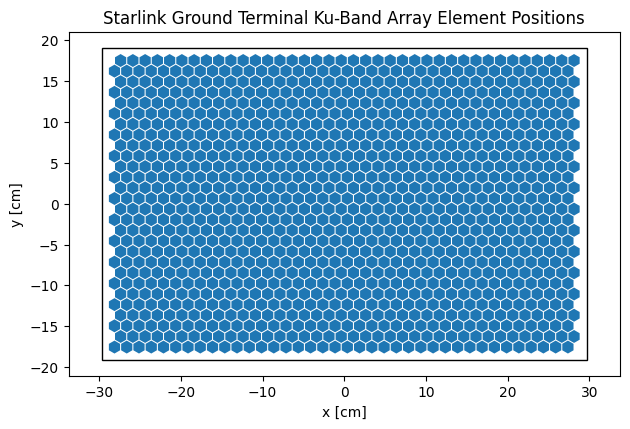

In [ ]:
ax = full_dishy.showxy(
    alpha=1,
    rs=1.22,
    unit_shape="hexagon",
)
bound = plt.Rectangle((-59.4 / 2, -38.3 / 2), 59.4, 38.2, fill=False)
ax.add_patch(
    bound,
)
ax.grid(False)
ax.set_title("Starlink Ground Terminal Ku-Band Array Element Positions")
plt.tight_layout()